<a href="https://colab.research.google.com/github/Geethanjali295/ML-PROJECT/blob/main/Copy_of_DAY_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#ANN
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input

In [ ]:
iris=sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
le=LabelEncoder()
iris['species']=le.fit_transform(iris['species'])
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
iris.shape

(150, 5)

In [ ]:
x=iris.drop(columns=['species'])
y=iris['species']
x_train,x_test,y_yrain,y_test=train_test_split(x,y,test_size=.25,random_state=12)
x_train.shape

(112, 4)

In [ ]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [ ]:
model=Sequential()
model.add(Input(shape=(4,)))  #SL,SW,PL,PW 4 features
model.add(Dense(10,activation='relu'))   #10 neurons
model.add(Dense(3,activation='softmax'))  #species 3


In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
learned=model.fit(x_train,y_yrain,epochs=100,batch_size=10,verbose=1,validation_data=(x_test,y_test))   #100 iterations
lose,accuracy=model.evaluate(x_test,y_test)
print("test accuracy",accuracy)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9585 - loss: 0.1286 - val_accuracy: 0.9474 - val_loss: 0.1539
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9727 - loss: 0.1217 - val_accuracy: 0.9474 - val_loss: 0.1502
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9807 - loss: 0.1043 - val_accuracy: 0.9474 - val_loss: 0.1479
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9708 - loss: 0.1020 - val_accuracy: 0.9474 - val_loss: 0.1440
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9817 - loss: 0.1005 - val_accuracy: 0.9474 - val_loss: 0.1424
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9637 - loss: 0.1247 - val_accuracy: 0.9474 - val_loss: 0.1431
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9799 - loss: 0.1059 - val_accuracy: 0.9474 - val_loss: 0.1408
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9846 - loss: 0.0929 - val_accuracy: 0.

In [ ]:
predictions=model.predict(x_test)
predicted_class=np.argmax(predictions,axis=1)
predicted_class

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


array([0, 2, 0, 1, 2, 2, 2, 0, 2, 0, 1, 0, 0, 0, 1, 2, 2, 1, 0, 1, 0, 1,
       2, 1, 0, 2, 2, 1, 0, 1, 0, 1, 2, 0, 2, 0, 1, 1])

In [ ]:
y_test

,species
40,0
146,2
38,0
99,1
143,2
116,2
148,2
39,0
135,2
23,0


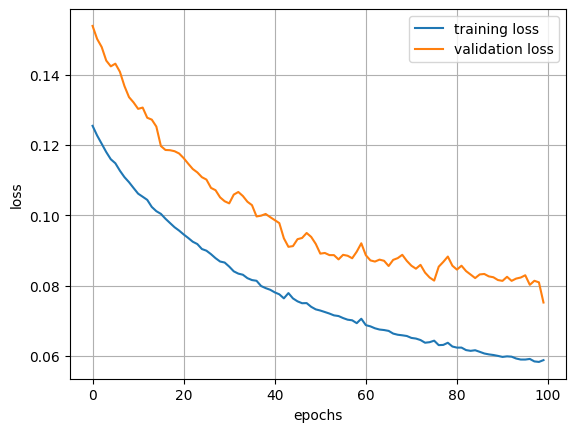

In [ ]:
plt.plot(learned.history['loss'],label='training loss')
plt.plot(learned.history['val_loss'],label='validation loss')
plt.legend()
plt.grid(True)
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()

In [ ]:
new_data=np.array([[5.1,3.5,1.4,0.2],[6.0,2.7,4.2,1.3]])
new_data=scaler.transform(new_data)
predictions=model.predict(new_data)
predicted_class=np.argmax(predictions,axis=1)
predicted_class

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([0, 1])

In [ ]:
#breast cancer
df=pd.read_csv('/content/Copy of breastcancer.csv')
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [ ]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
dff=df.drop(columns=['id','Unnamed: 32'])
dff.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
dff['diagnosis'].nunique()

2

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
dff['diagnosis']=le.fit_transform(dff['diagnosis'])
dff.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


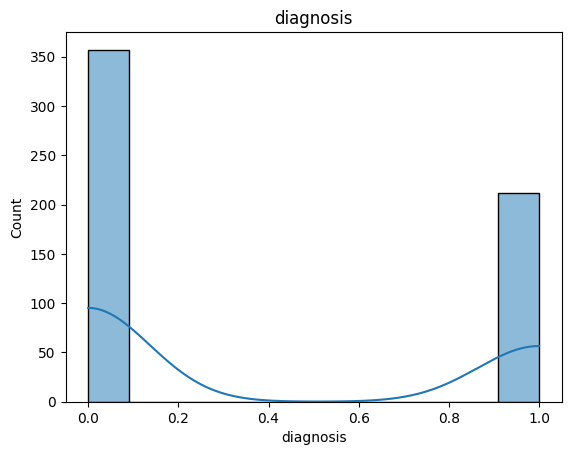

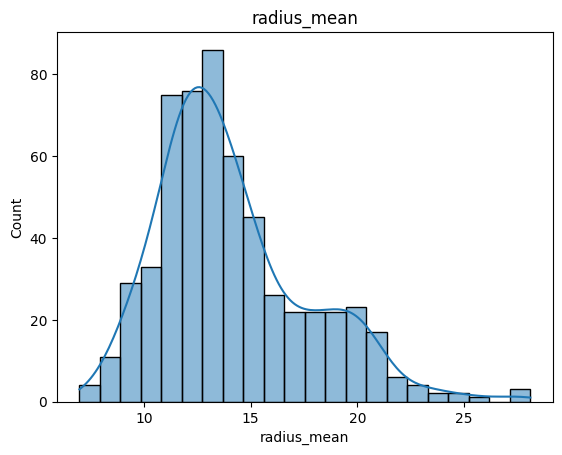

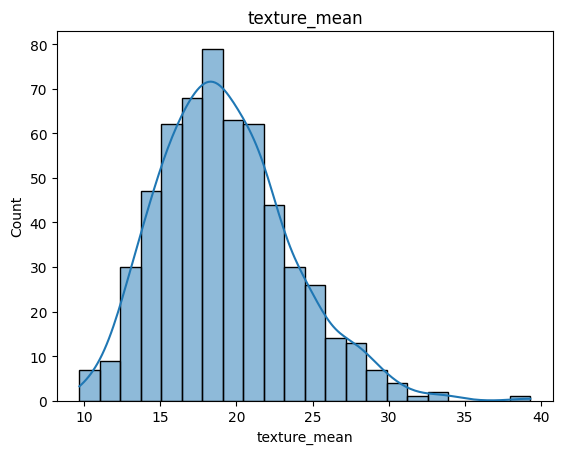

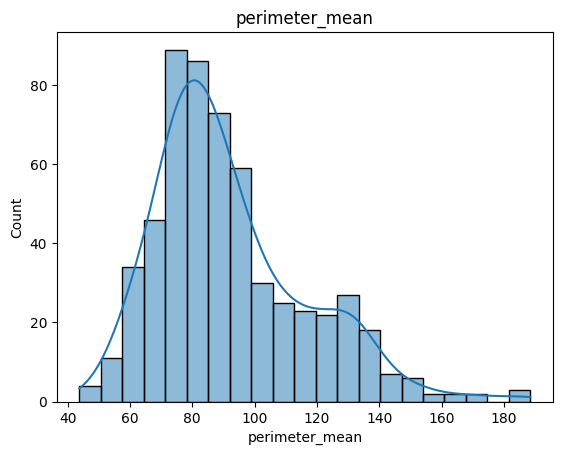

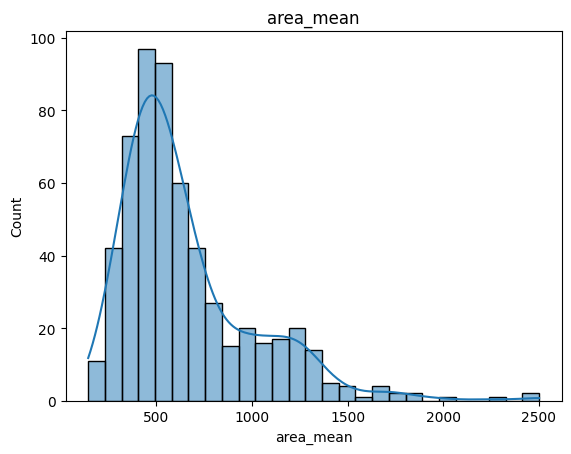

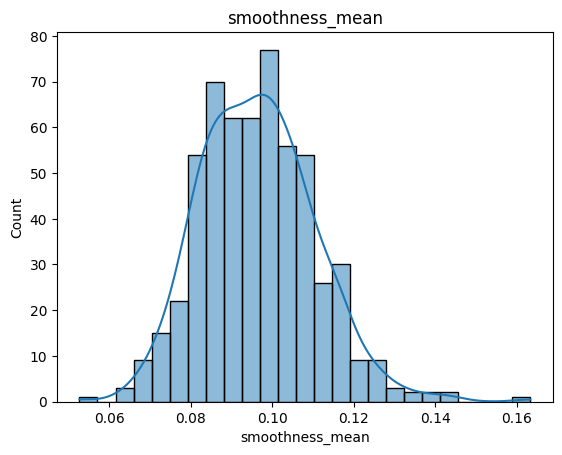

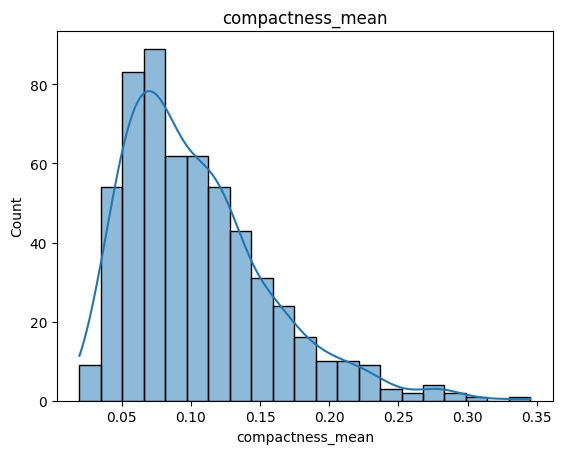

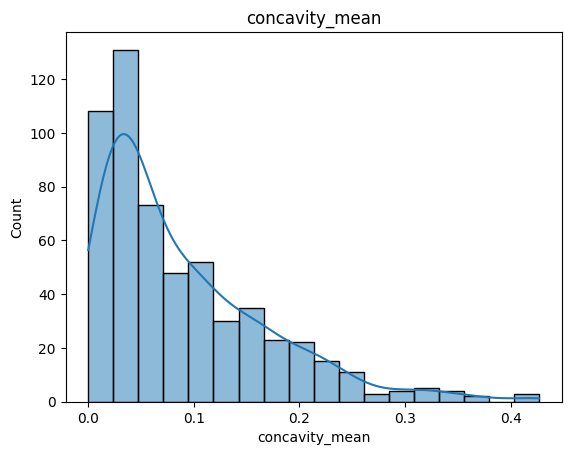

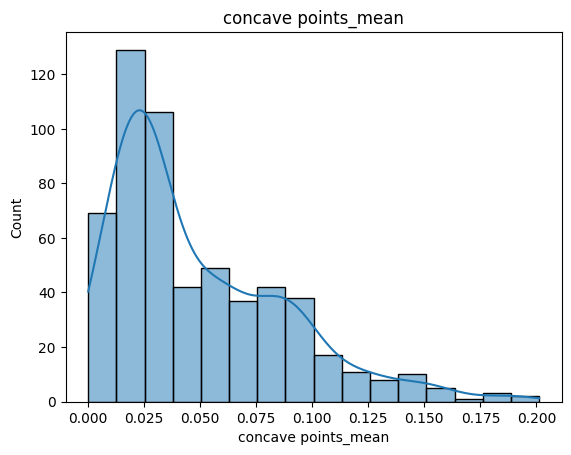

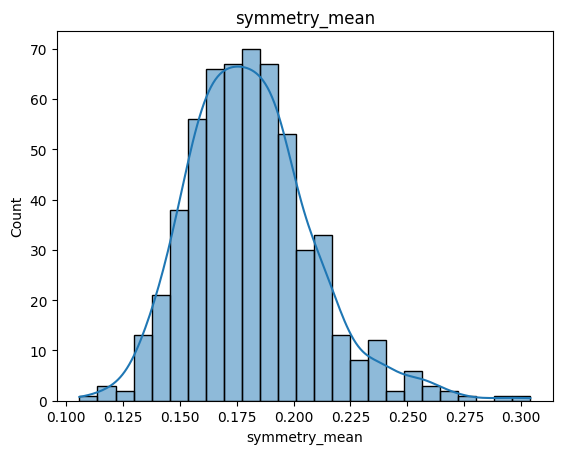

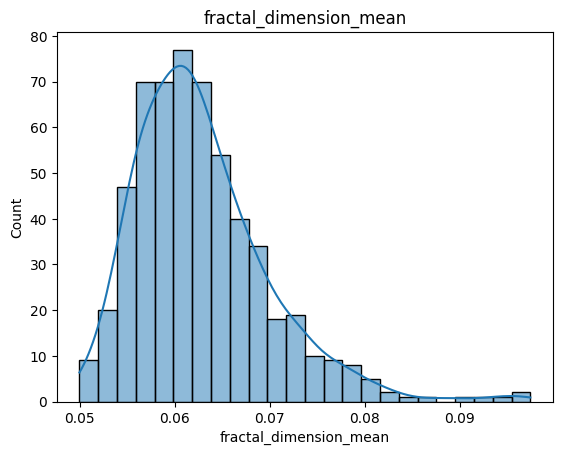

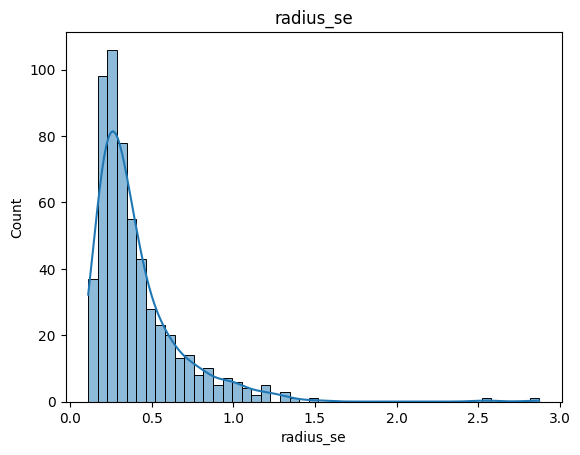

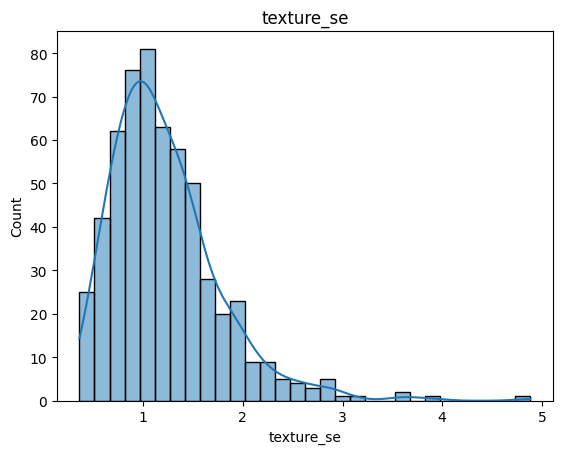

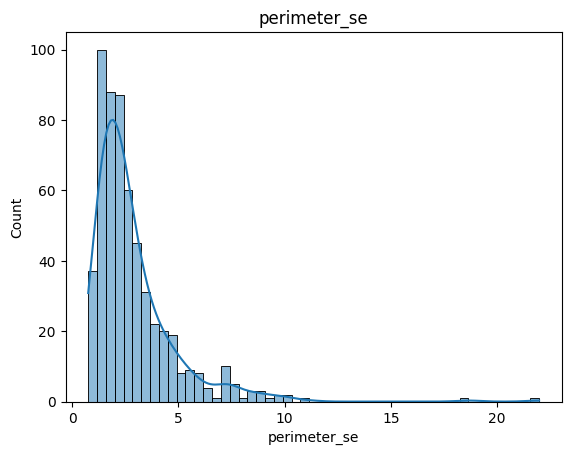

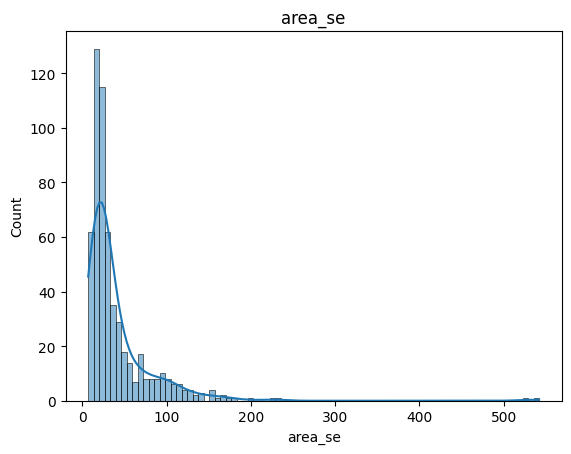

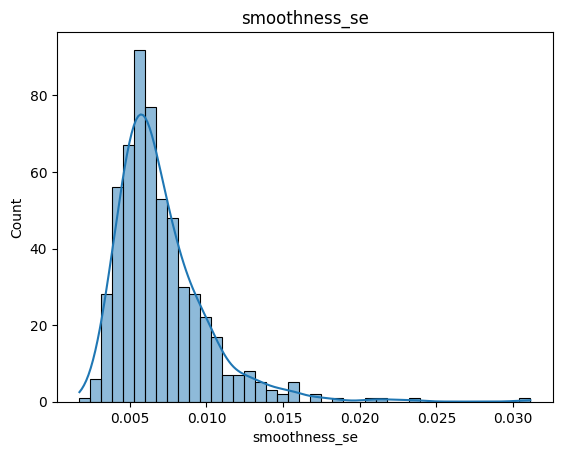

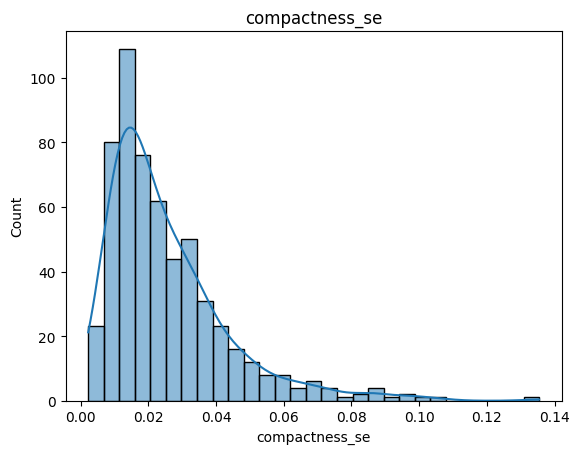

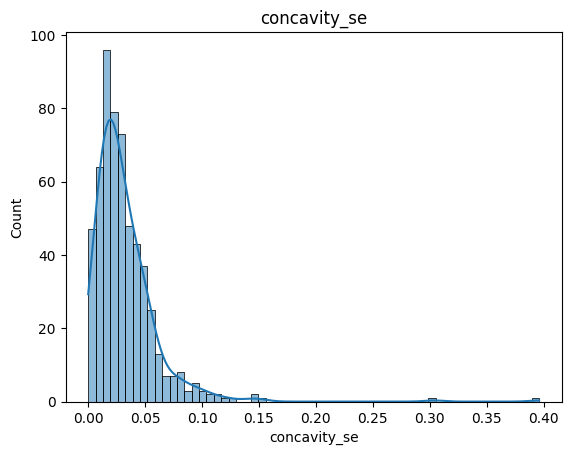

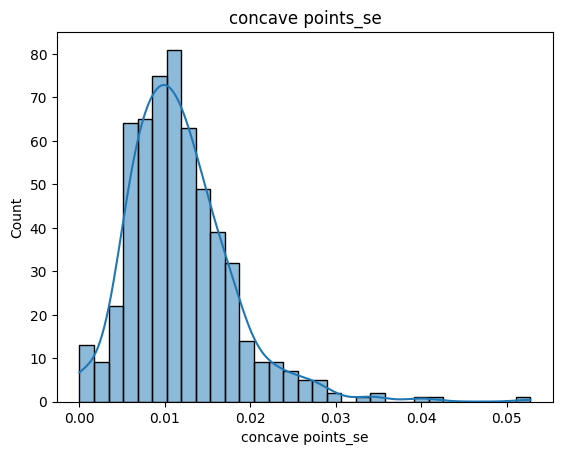

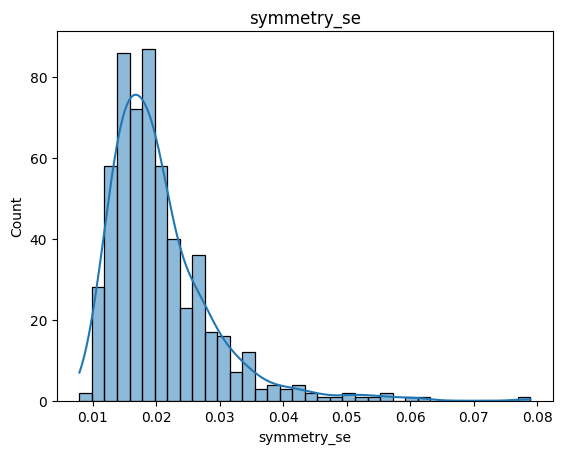

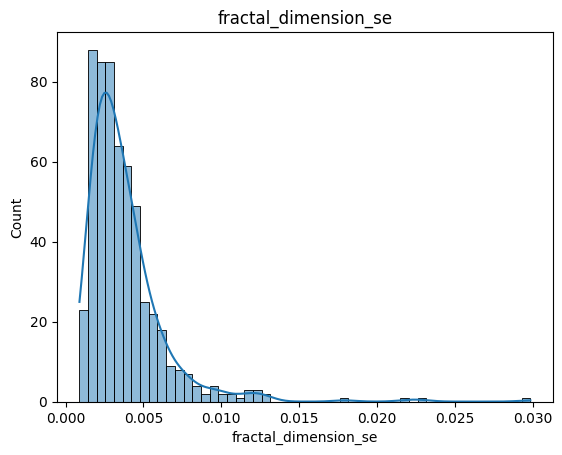

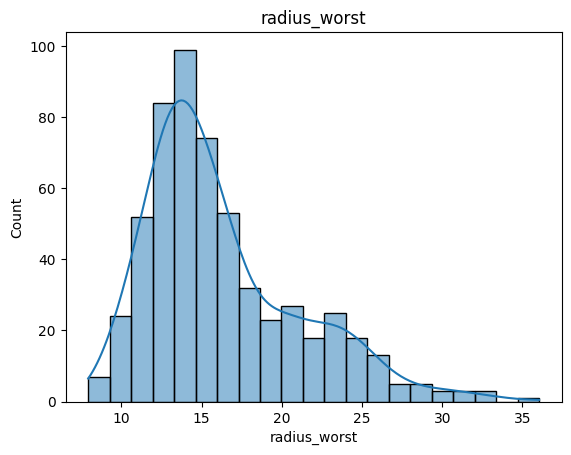

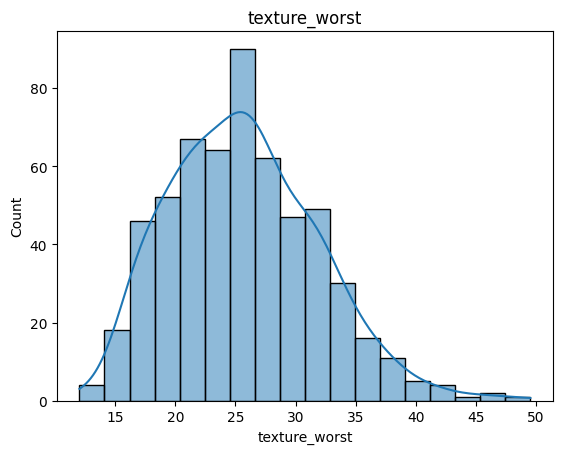

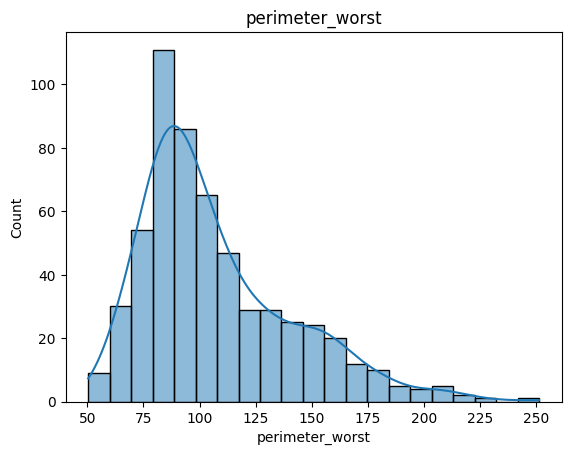

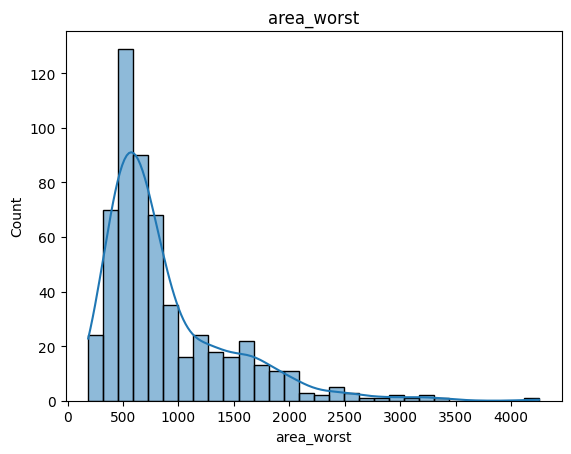

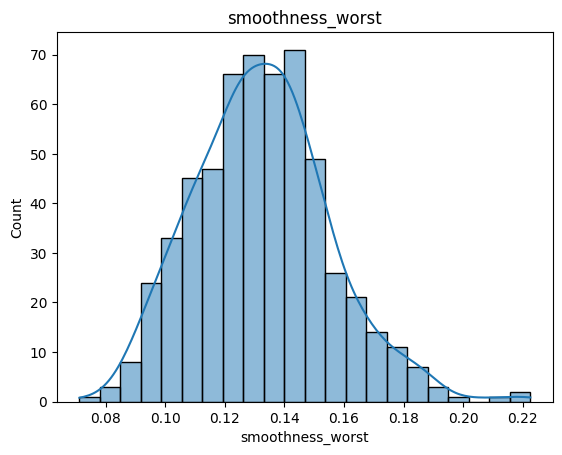

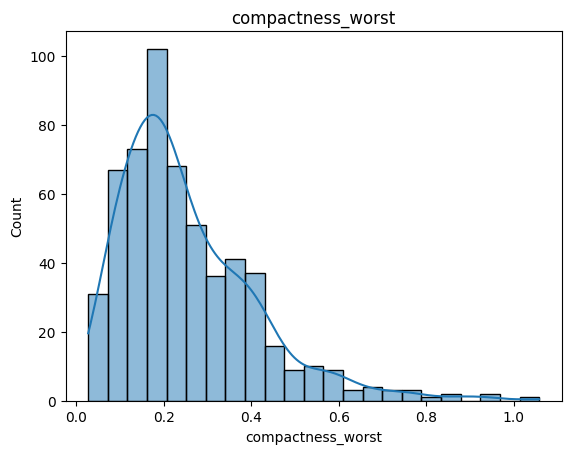

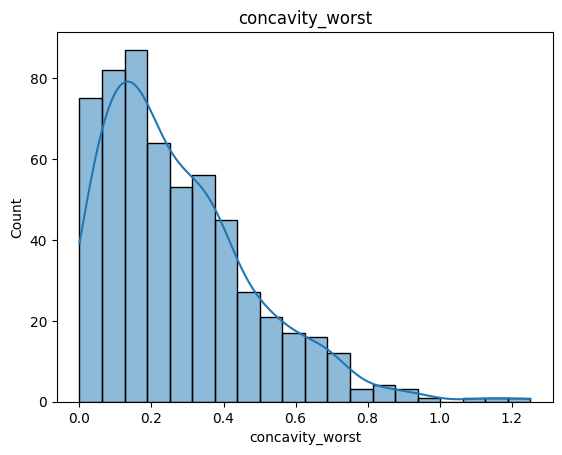

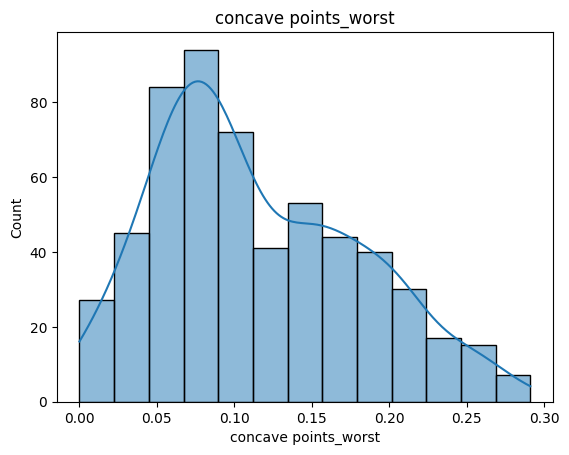

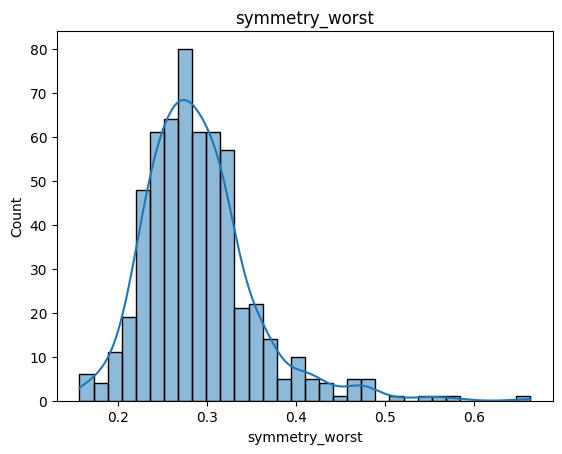

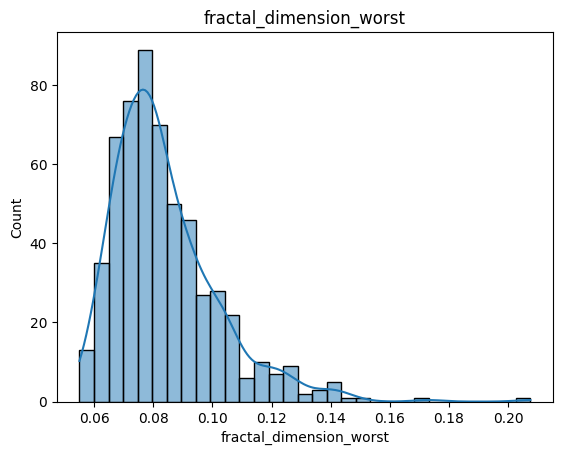

In [ ]:
numerical_cols=dff.select_dtypes(include=np.number).columns
numerical_cols
for col in numerical_cols:
  sns.histplot(dff[col],kde=True)
  plt.title(col)
  plt.show()

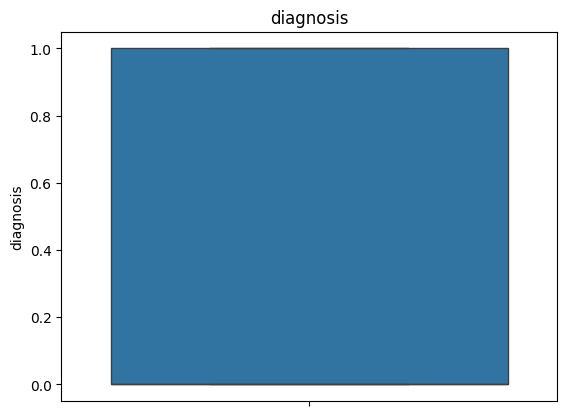

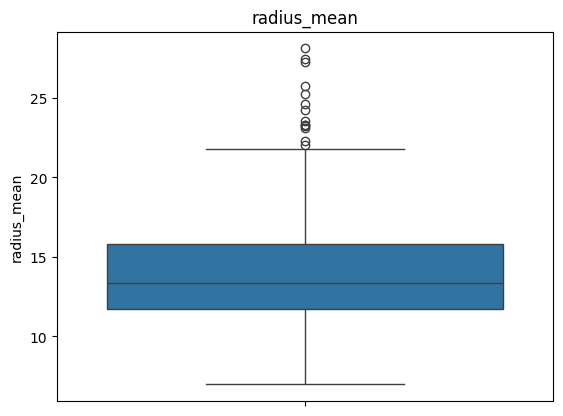

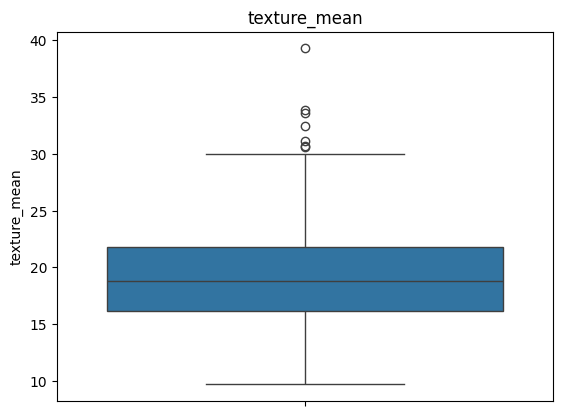

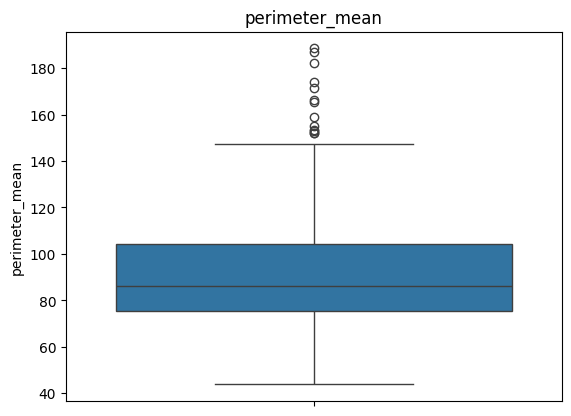

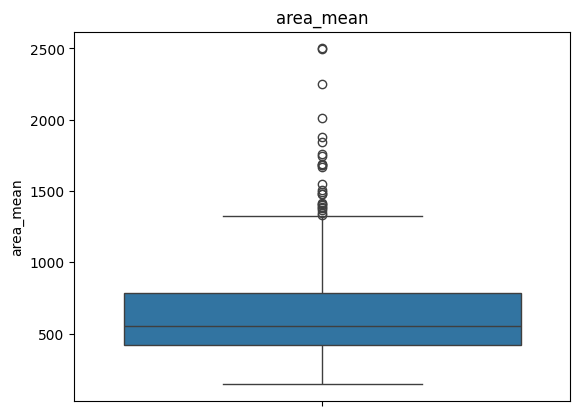

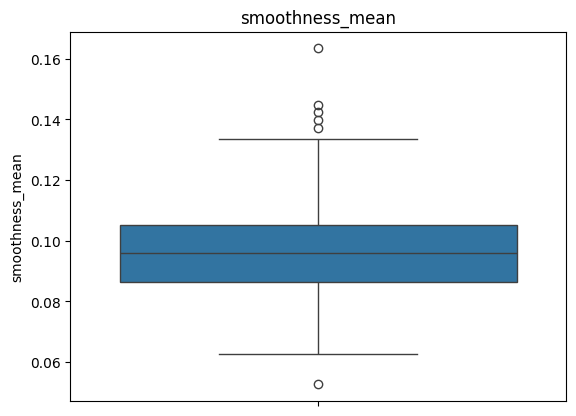

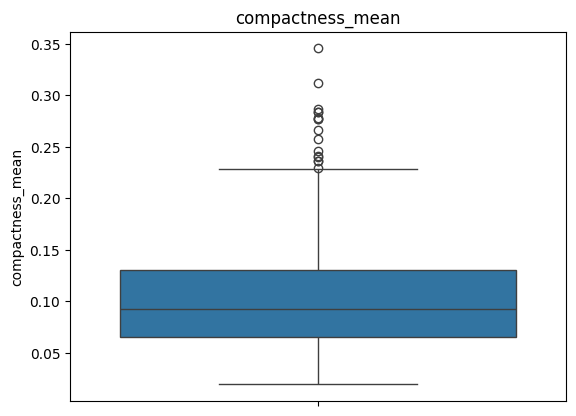

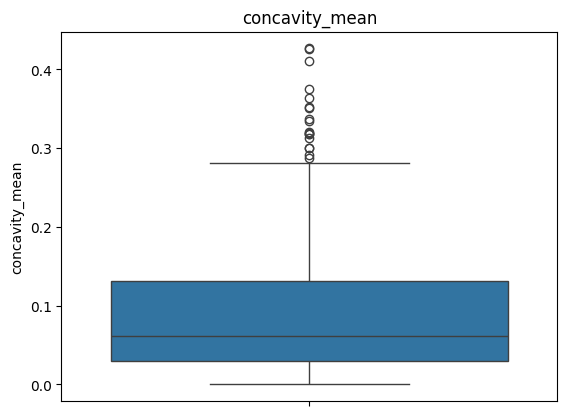

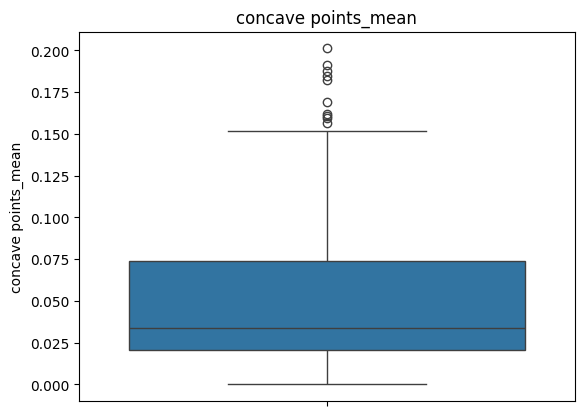

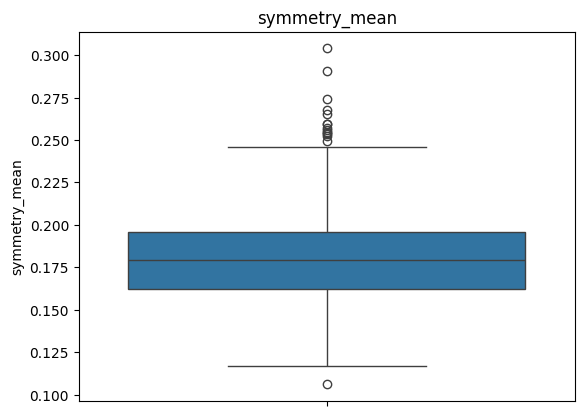

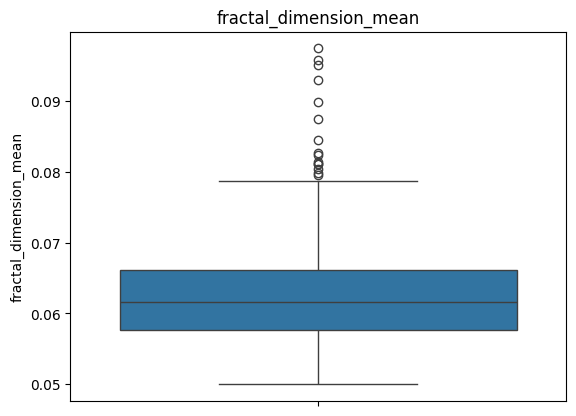

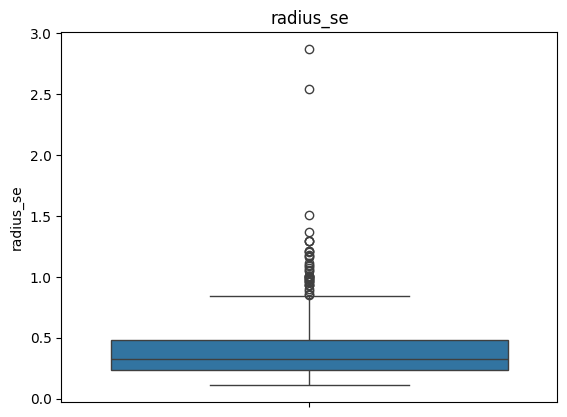

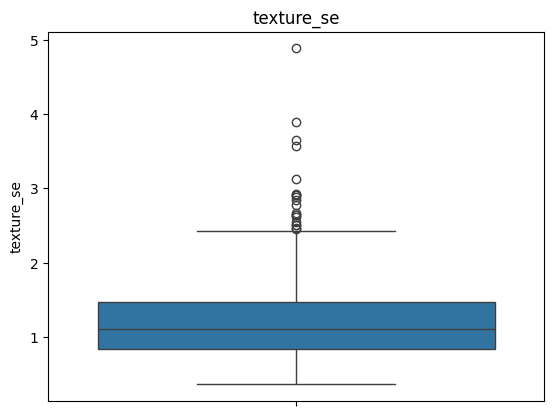

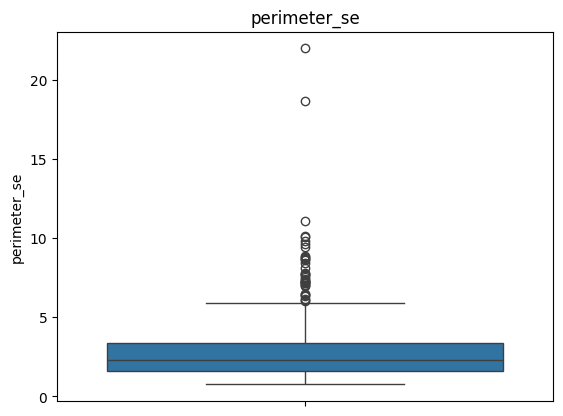

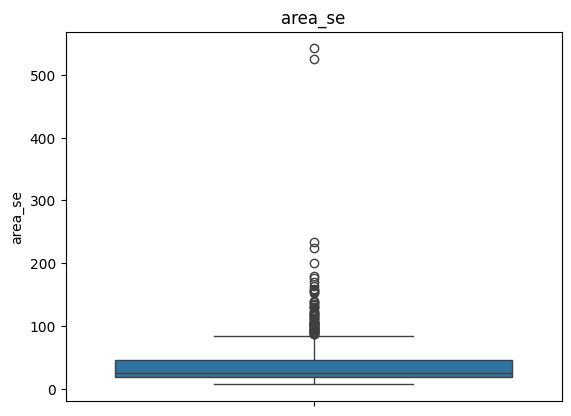

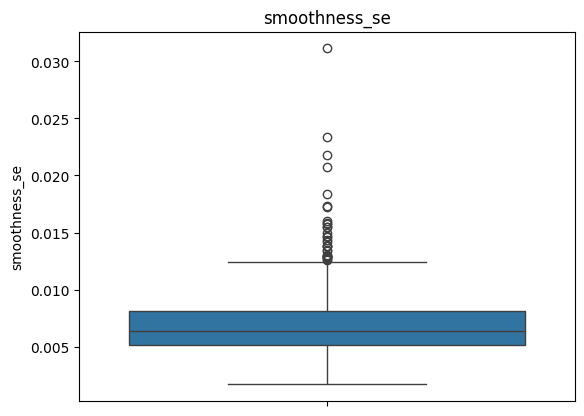

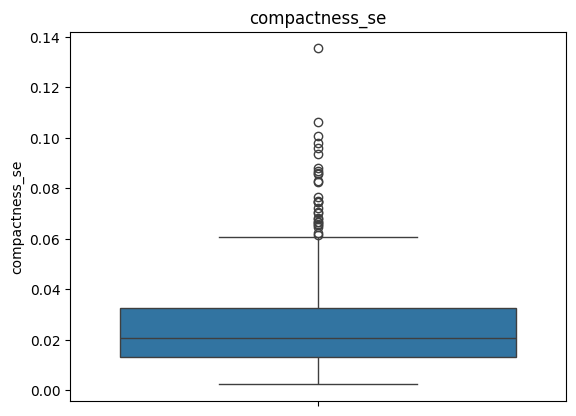

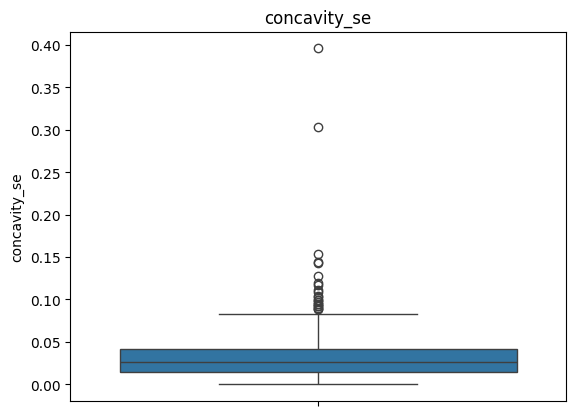

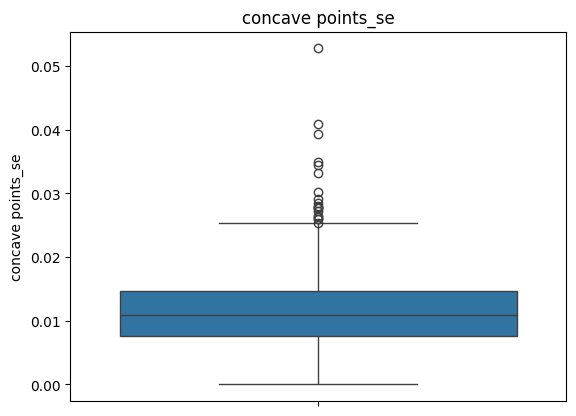

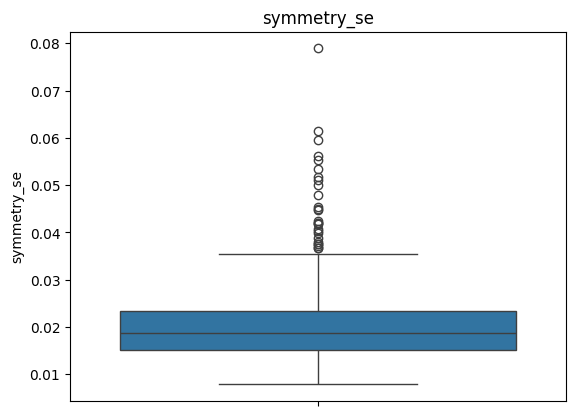

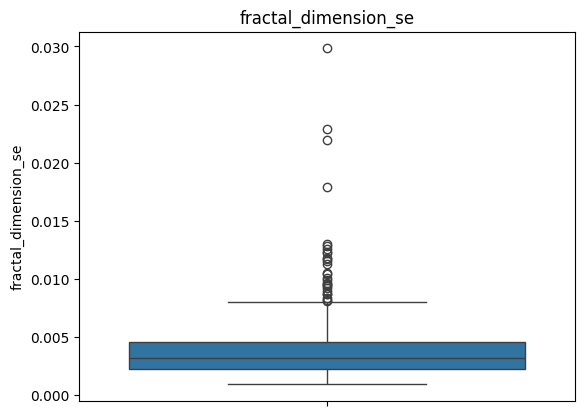

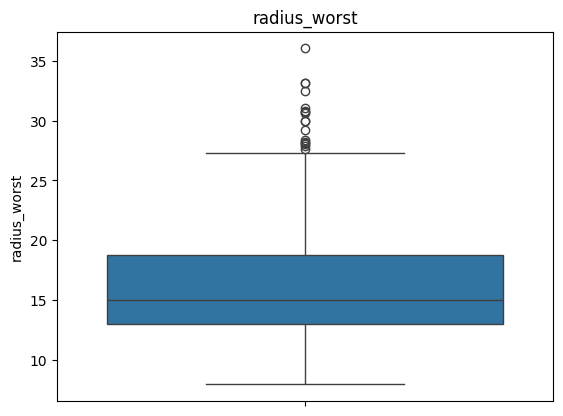

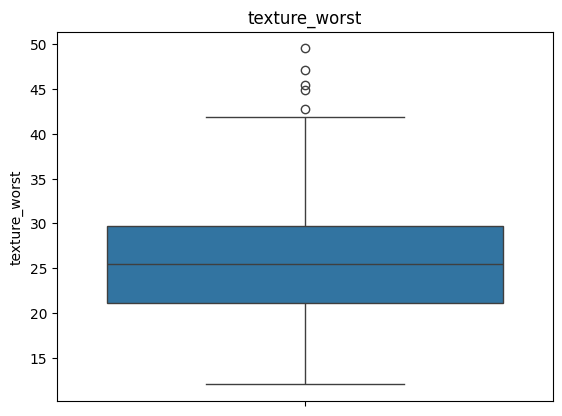

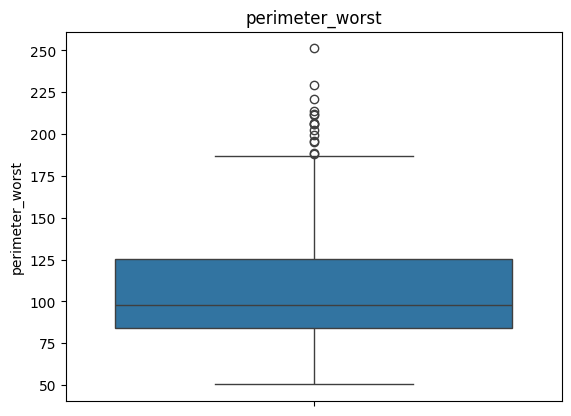

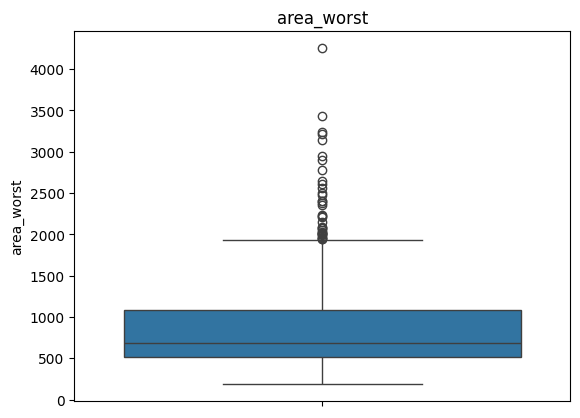

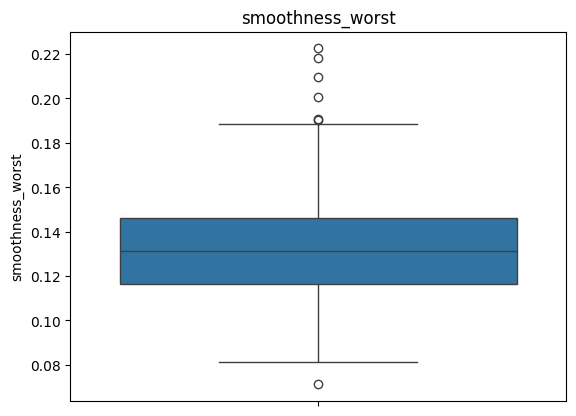

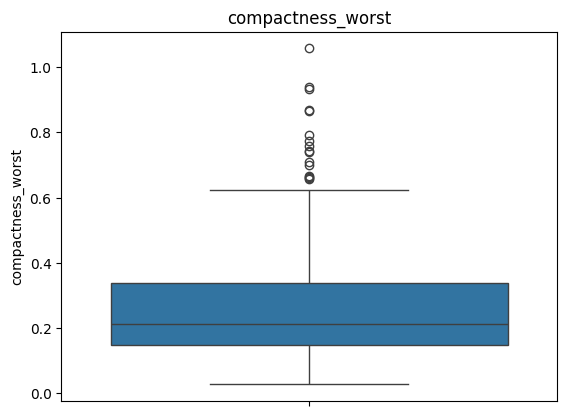

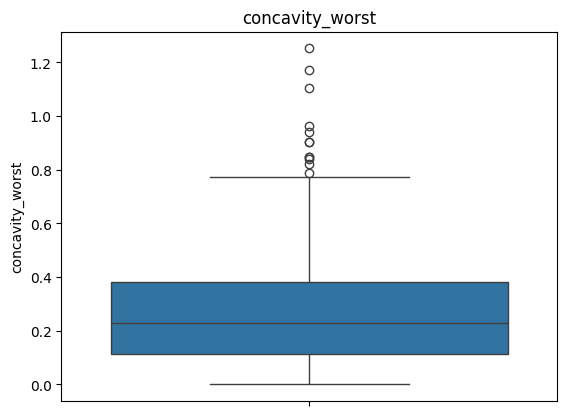

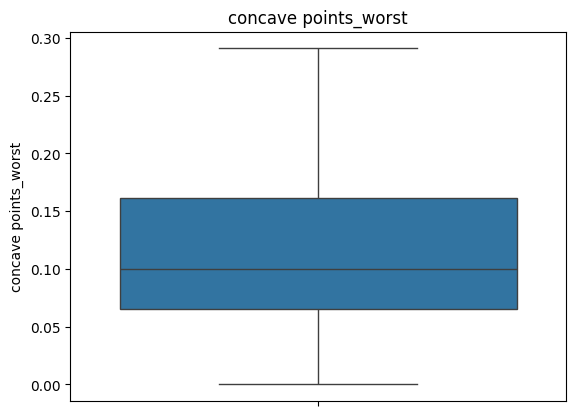

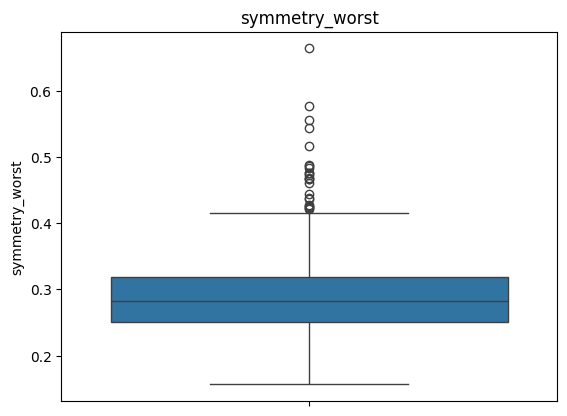

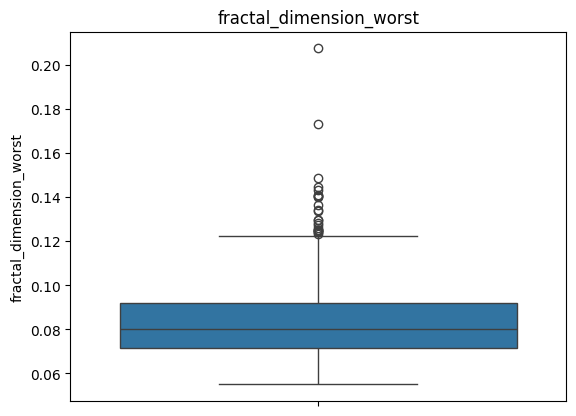

In [ ]:
numerical_cols=dff.select_dtypes(include=np.number).columns
numerical_cols
for col in numerical_cols:
  sns.boxplot(dff[col])
  plt.title(col)
  plt.show()

In [ ]:
from scipy.stats import skew
skew_values=dff[numerical_cols].skew()
print(skew_values)

diagnosis                  0.528461
radius_mean                0.942380
texture_mean               0.650450
perimeter_mean             0.990650
area_mean                  1.645732
smoothness_mean            0.456324
compactness_mean           1.190123
concavity_mean             1.401180
concave points_mean        1.171180
symmetry_mean              0.725609
fractal_dimension_mean     1.304489
radius_se                  3.088612
texture_se                 1.646444
perimeter_se               3.443615
area_se                    5.447186
smoothness_se              2.314450
compactness_se             1.902221
concavity_se               5.110463
concave points_se          1.444678
symmetry_se                2.195133
fractal_dimension_se       3.923969
radius_worst               1.103115
texture_worst              0.498321
perimeter_worst            1.128164
area_worst                 1.859373
smoothness_worst           0.415426
compactness_worst          1.473555
concavity_worst            1

In [ ]:
highly_skewed_columns=skew_values[abs(skew_values)>0.75].index
for col in highly_skewed_columns:
  if col !='diagnosis':
    dff[col]=np.log1p(dff[col])

print("skewness after log transformation")
display(dff[highly_skewed_columns].skew())

skewness after log transformation


,0
radius_mean,0.348744
perimeter_mean,0.328800
area_mean,0.287328
compactness_mean,1.043195
concavity_mean,1.206982
concave points_mean,1.083180
fractal_dimension_mean,1.272294
radius_se,1.713417
texture_se,0.629526
perimeter_se,1.025375


<Axes: >

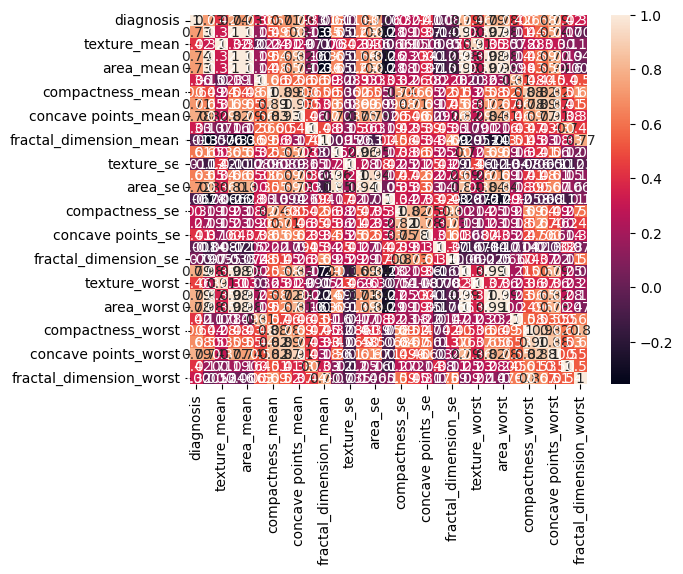

In [ ]:
dff.corr()
sns.heatmap(dff.corr(),annot=True)

In [ ]:
x=dff.drop(columns=['diagnosis'])
y=dff['diagnosis']
x_train,x_test,y_yrain,y_test=train_test_split(x,y,test_size=.25,random_state=12)
x_train.shape

(426, 30)

In [ ]:
dff

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,2.943913,10.38,4.818667,6.909753,0.11840,0.244983,0.262441,0.137237,0.2419,...,3.272606,17.33,5.223594,7.610853,0.16220,0.510185,0.537604,0.2654,0.378505,0.112346
1,1,3.071303,17.77,4.897093,7.190676,0.08474,0.075701,0.083330,0.067818,0.1812,...,3.257712,23.41,5.073923,7.579168,0.12380,0.171092,0.216401,0.1860,0.242946,0.085278
2,1,3.029650,21.25,4.875197,7.093405,0.10960,0.148334,0.180153,0.120357,0.2069,...,3.201526,25.53,5.033701,7.444249,0.14440,0.353821,0.371839,0.2430,0.308440,0.083955
3,1,2.519308,20.38,4.364117,5.958683,0.14250,0.249902,0.216240,0.100026,0.2597,...,2.766948,26.50,4.603869,6.343353,0.20980,0.623958,0.522893,0.2575,0.509104,0.159565
4,1,3.058237,14.34,4.913390,7.168580,0.10030,0.124692,0.180653,0.099212,0.1809,...,3.158701,16.67,5.031744,7.362645,0.13740,0.186480,0.336472,0.1625,0.212204,0.073975
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,3.116178,22.39,4.962845,7.299797,0.11100,0.109661,0.218252,0.130063,0.1726,...,3.275256,26.40,5.118592,7.614805,0.14100,0.191694,0.344086,0.2216,0.187309,0.068733
565,1,3.050694,28.25,4.884316,7.140453,0.09780,0.098396,0.134531,0.093408,0.1752,...,3.206398,38.25,5.049856,7.457032,0.11660,0.175800,0.278767,0.1628,0.228887,0.064260
566,1,2.867899,28.08,4.694096,6.755885,0.08455,0.097399,0.088478,0.051662,0.1590,...,2.994732,34.12,4.849684,7.025538,0.11390,0.269569,0.292893,0.1418,0.200325,0.075293
567,1,3.072693,29.33,4.949469,7.143618,0.11780,0.244514,0.301141,0.141500,0.2397,...,3.286161,39.42,5.223594,7.507690,0.16500,0.624922,0.662018,0.2650,0.342667,0.116894


In [ ]:
x_train

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
12,3.004196,24.80,4.893352,7.024649,0.09740,0.219778,0.187724,0.105980,0.2397,0.075107,...,3.089223,29.94,5.028475,7.195187,0.10370,0.329520,0.310348,0.17670,0.275812,0.097399
472,2.767576,14.93,4.579339,6.533643,0.08098,0.082031,0.053910,0.031702,0.1687,0.055141,...,2.900322,18.22,4.727388,6.810804,0.10650,0.246157,0.273913,0.11470,0.238072,0.079486
21,2.351756,12.44,4.116432,5.616407,0.10240,0.062900,0.029132,0.020547,0.1815,0.066770,...,2.418589,15.66,4.191623,5.755426,0.13240,0.108675,0.084957,0.06227,0.219136,0.074857
287,2.631169,13.12,4.417514,6.247849,0.06955,0.036612,0.022348,0.011642,0.1337,0.054308,...,2.682390,15.54,4.481872,6.359574,0.09616,0.108585,0.112078,0.05366,0.207746,0.066864
80,2.521721,20.97,4.314952,5.997695,0.11020,0.089493,0.044887,0.022084,0.1842,0.067705,...,2.646884,32.16,4.448867,6.265491,0.15570,0.154950,0.161694,0.06127,0.243887,0.084810
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
432,3.053057,19.54,4.903792,7.131699,0.11330,0.138805,0.193344,0.118583,0.1724,0.058769,...,3.136798,25.07,4.990433,7.299797,0.16650,0.257893,0.425790,0.21730,0.264823,0.077655
259,2.805177,33.56,4.651099,6.614592,0.10630,0.151776,0.161353,0.080649,0.2091,0.064382,...,2.969902,49.54,4.846547,6.943122,0.18830,0.442375,0.451267,0.20140,0.300993,0.113686
241,2.596746,15.04,4.377140,6.168564,0.07926,0.033367,0.010475,0.011019,0.1546,0.055945,...,2.653242,20.37,4.440885,6.299684,0.10370,0.074885,0.060559,0.04052,0.254720,0.065629
253,2.906901,17.08,4.736198,6.834324,0.10080,0.099031,0.119204,0.080224,0.1813,0.054611,...,3.037354,25.09,4.882044,7.109062,0.14160,0.215515,0.291026,0.18570,0.272924,0.078007


In [ ]:
y_test

,diagnosis
14,1
334,0
457,0
101,0
346,0
...,...
231,0
363,0
326,0
306,0


In [ ]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [ ]:
model=Sequential()
model.add(Input(shape=(30,)))
model.add(Dense(10,activation='relu'))   #hidden layer 10
model.add(Dense(2,activation='sigmoid'))    #output

In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
learned=model.fit(x_train,y_yrain,epochs=100,batch_size=10,verbose=1,validation_data=(x_test,y_test))   #100 iterations
lose,accuracy=model.evaluate(x_test,y_test)
print("test accuracy",accuracy)

Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4535 - loss: 1.0050 - val_accuracy: 0.6434 - val_loss: 0.7193
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6668 - loss: 0.7953 - val_accuracy: 0.8322 - val_loss: 0.4596
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8693 - loss: 0.3940 - val_accuracy: 0.8741 - val_loss: 0.3343
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9145 - loss: 0.3337 - val_accuracy: 0.8951 - val_loss: 0.2634
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9413 - loss: 0.2279 - val_accuracy: 0.9091 - val_loss: 0.2243
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9568 - loss: 0.1825 - val_accuracy: 0.9231 - val_loss: 0.2029
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9591 - loss: 0.1764 - val_accuracy: 0.9231 - val_loss: 0.1886
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9672 - loss: 0.1294 - val_accuracy: 0.9301 - 

In [ ]:
predictions=model.predict(x_test)
predicted_class=np.argmax(predictions,axis=1)
predicted_class

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


array([1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

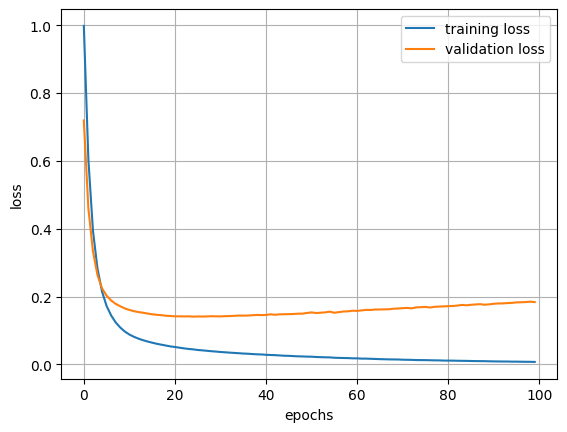

In [ ]:
plt.plot(learned.history['loss'],label='training loss')
plt.plot(learned.history['val_loss'],label='validation loss')
plt.legend()
plt.grid(True)
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()

In [ ]:
#penguin
df=sns.load_dataset('penguins')
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [ ]:
df.isnull().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


In [ ]:
len_mean=df['bill_length_mm'].mean()
len_mean

np.float64(43.9219298245614)

In [ ]:
dep_mean=df['bill_depth_mm'].mean()
dep_mean

np.float64(17.151169590643278)

In [ ]:
flipper_len=df['flipper_length_mm'].mean()
flipper_len

np.float64(200.91520467836258)

In [ ]:
df['sex']=df['sex'].fillna(df['sex'].mode()[0])
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,Male
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,Male
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                344 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [ ]:
df['flipper_length_mm']=df['flipper_length_mm'].fillna(flipper_len)
df['flipper_length_mm']

,flipper_length_mm
0,181.000000
1,186.000000
2,195.000000
3,200.915205
4,193.000000
...,...
339,200.915205
340,215.000000
341,222.000000
342,212.000000


In [ ]:
df['bill_length_mm']=df['bill_length_mm'].fillna(len_mean)
df['bill_length_mm']

,bill_length_mm
0,39.10000
1,39.50000
2,40.30000
3,43.92193
4,36.70000
...,...
339,43.92193
340,46.80000
341,50.40000
342,45.20000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     344 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  344 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                344 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


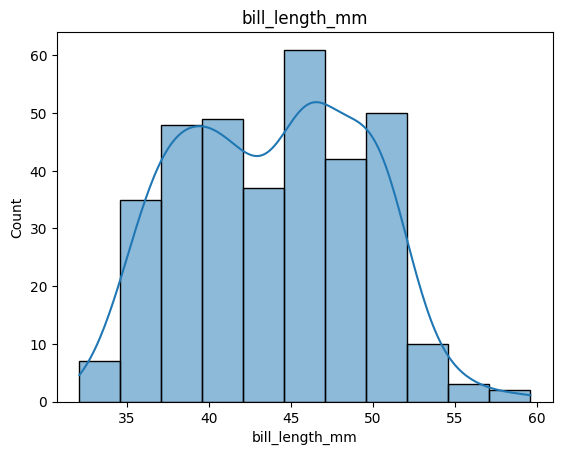

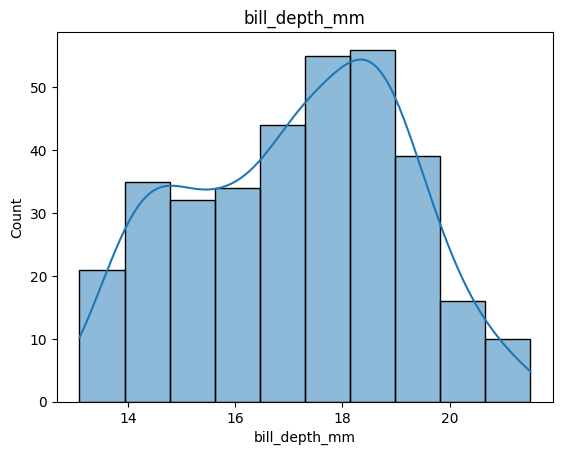

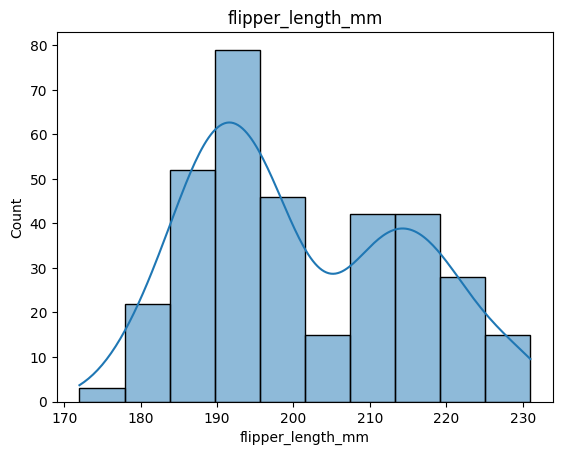

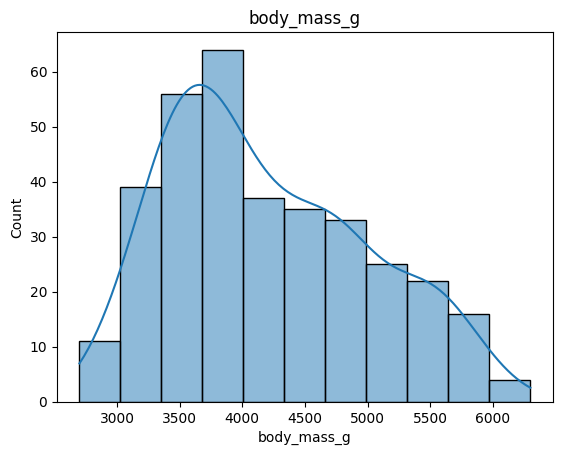

In [ ]:
numerical_cols=df.select_dtypes(include=np.number).columns
numerical_cols
for col in numerical_cols:
  sns.histplot(df[col],kde=True)
  plt.title(col)
  plt.show()

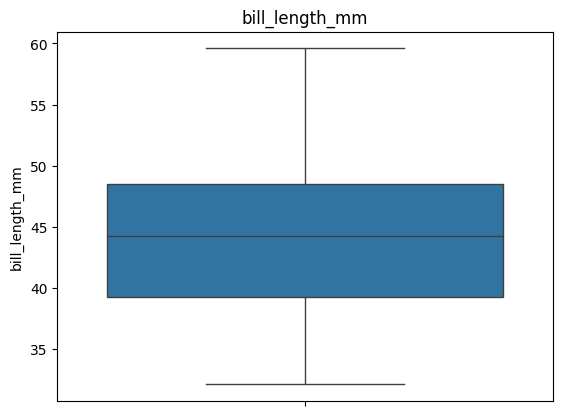

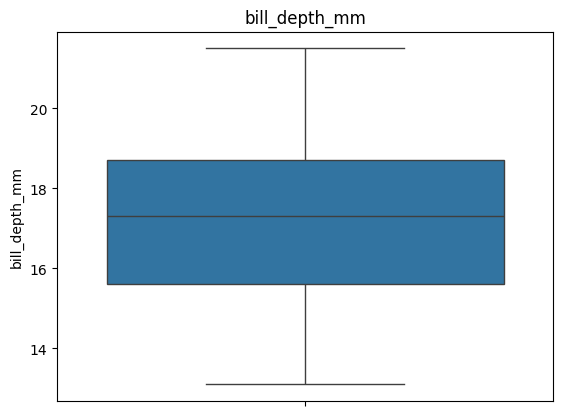

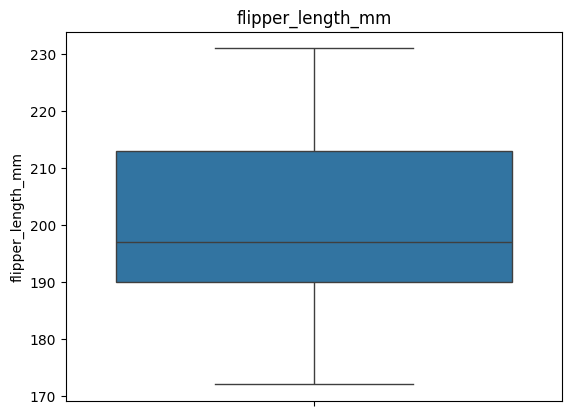

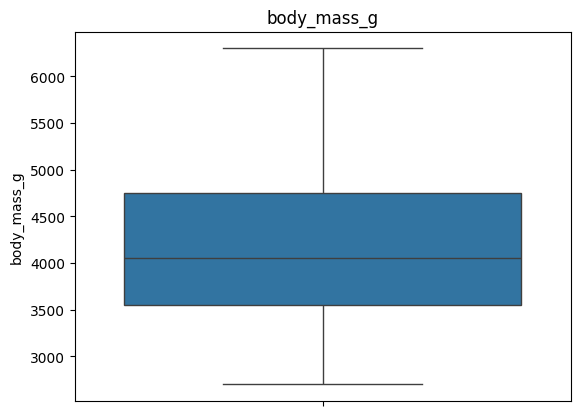

In [ ]:
numerical_cols=df.select_dtypes(include=np.number).columns
numerical_cols
for col in numerical_cols:
  sns.boxplot(df[col])
  plt.title(col)
  plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['species']=le.fit_transform(df['species'])
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,0,Torgersen,39.10000,18.7,181.000000,3750.0,Male
1,0,Torgersen,39.50000,17.4,186.000000,3800.0,Female
2,0,Torgersen,40.30000,18.0,195.000000,3250.0,Female
3,0,Torgersen,43.92193,NaN,200.915205,NaN,Male
4,0,Torgersen,36.70000,19.3,193.000000,3450.0,Female


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['sex']=le.fit_transform(df['sex'])
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,0,Torgersen,39.10000,18.7,181.000000,3750.0,1
1,0,Torgersen,39.50000,17.4,186.000000,3800.0,0
2,0,Torgersen,40.30000,18.0,195.000000,3250.0,0
3,0,Torgersen,43.92193,NaN,200.915205,NaN,1
4,0,Torgersen,36.70000,19.3,193.000000,3450.0,0


In [ ]:
df['island'].nunique()

3

In [ ]:
from sklearn.preprocessing import OneHotEncoder
oh=OneHotEncoder()
df=pd.get_dummies(df,columns=['island'])
df

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,island_0,island_1,island_2
0,0,39.10000,18.7,181.000000,3750.0,1,False,False,True
1,0,39.50000,17.4,186.000000,3800.0,0,False,False,True
2,0,40.30000,18.0,195.000000,3250.0,0,False,False,True
3,0,43.92193,NaN,200.915205,NaN,1,False,False,True
4,0,36.70000,19.3,193.000000,3450.0,0,False,False,True
...,...,...,...,...,...,...,...,...,...
339,2,43.92193,NaN,200.915205,NaN,1,True,False,False
340,2,46.80000,14.3,215.000000,4850.0,0,True,False,False
341,2,50.40000,15.7,222.000000,5750.0,1,True,False,False
342,2,45.20000,14.8,212.000000,5200.0,0,True,False,False


In [ ]:
bool_cols=df.select_dtypes(include='bool').columns
df[bool_cols]=df[bool_cols].astype(int)
df

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,island_0,island_1,island_2
0,0,39.10000,18.7,181.000000,3750.0,1,0,0,1
1,0,39.50000,17.4,186.000000,3800.0,0,0,0,1
2,0,40.30000,18.0,195.000000,3250.0,0,0,0,1
3,0,43.92193,NaN,200.915205,NaN,1,0,0,1
4,0,36.70000,19.3,193.000000,3450.0,0,0,0,1
...,...,...,...,...,...,...,...,...,...
339,2,43.92193,NaN,200.915205,NaN,1,1,0,0
340,2,46.80000,14.3,215.000000,4850.0,0,1,0,0
341,2,50.40000,15.7,222.000000,5750.0,1,1,0,0
342,2,45.20000,14.8,212.000000,5200.0,0,1,0,0


In [ ]:
df=pd.get_dummies(df,columns=['species'])
df

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,island_0,island_1,island_2,species_0,species_1,species_2
0,39.10000,18.7,181.000000,3750.0,1,0,0,1,True,False,False
1,39.50000,17.4,186.000000,3800.0,0,0,0,1,True,False,False
2,40.30000,18.0,195.000000,3250.0,0,0,0,1,True,False,False
3,43.92193,NaN,200.915205,NaN,1,0,0,1,True,False,False
4,36.70000,19.3,193.000000,3450.0,0,0,0,1,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...
339,43.92193,NaN,200.915205,NaN,1,1,0,0,False,False,True
340,46.80000,14.3,215.000000,4850.0,0,1,0,0,False,False,True
341,50.40000,15.7,222.000000,5750.0,1,1,0,0,False,False,True
342,45.20000,14.8,212.000000,5200.0,0,1,0,0,False,False,True


In [ ]:
bool_cols=df.select_dtypes(include='bool').columns
df[bool_cols]=df[bool_cols].astype(int)
df

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,island_0,island_1,island_2,species_0,species_1,species_2
0,39.10000,18.7,181.000000,3750.0,1,0,0,1,1,0,0
1,39.50000,17.4,186.000000,3800.0,0,0,0,1,1,0,0
2,40.30000,18.0,195.000000,3250.0,0,0,0,1,1,0,0
3,43.92193,NaN,200.915205,NaN,1,0,0,1,1,0,0
4,36.70000,19.3,193.000000,3450.0,0,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
339,43.92193,NaN,200.915205,NaN,1,1,0,0,0,0,1
340,46.80000,14.3,215.000000,4850.0,0,1,0,0,0,0,1
341,50.40000,15.7,222.000000,5750.0,1,1,0,0,0,0,1
342,45.20000,14.8,212.000000,5200.0,0,1,0,0,0,0,1


In [ ]:
df_cleaned=df.dropna(subset=['body_mass_g'])
df_cleaned

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,island_0,island_1,island_2,species_0,species_1,species_2
0,39.1,18.7,181.0,3750.0,1,0,0,1,1,0,0
1,39.5,17.4,186.0,3800.0,0,0,0,1,1,0,0
2,40.3,18.0,195.0,3250.0,0,0,0,1,1,0,0
4,36.7,19.3,193.0,3450.0,0,0,0,1,1,0,0
5,39.3,20.6,190.0,3650.0,1,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
338,47.2,13.7,214.0,4925.0,0,1,0,0,0,0,1
340,46.8,14.3,215.0,4850.0,0,1,0,0,0,0,1
341,50.4,15.7,222.0,5750.0,1,1,0,0,0,0,1
342,45.2,14.8,212.0,5200.0,0,1,0,0,0,0,1


In [ ]:
x=df_cleaned.drop(columns=['body_mass_g'])
y=df_cleaned['body_mass_g']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.25,random_state=12)
x_train.shape

(256, 10)

In [ ]:
x_train

,bill_length_mm,bill_depth_mm,flipper_length_mm,sex,island_0,island_1,island_2,species_0,species_1,species_2
52,35.0,17.9,190.0,0,1,0,0,1,0,0
81,42.9,17.6,196.0,1,0,0,1,1,0,0
263,49.6,15.0,216.0,1,1,0,0,0,0,1
91,41.1,18.1,205.0,1,0,1,0,1,0,0
19,46.0,21.5,194.0,1,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...
131,43.1,19.2,197.0,1,0,0,1,1,0,0
242,46.5,14.5,213.0,0,1,0,0,0,0,1
254,49.1,14.8,220.0,0,1,0,0,0,0,1
156,52.7,19.8,197.0,1,0,1,0,0,1,0


In [ ]:
y_test

,body_mass_g
265,4900.0
189,4800.0
138,3400.0
276,4300.0
288,4700.0
...,...
190,2700.0
7,4675.0
325,5500.0
282,4400.0


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input

In [ ]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [ ]:
model=Sequential()
model.add(Input(shape=(10,))) # Changed input shape to 10
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(1,activation='linear'))

In [ ]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [ ]:
model.compile(optimizer='adam',loss='mse',metrics=['mae','mse','r2_score'])
learned=model.fit(x_train,y_train,epochs=100,batch_size=10,verbose=1,validation_data=(x_test,y_test))   #100 iterations
loss,mae,mse,r2=model.evaluate(x_test,y_test)
print("test loss",loss)
print("test mae",mae)
print("test mse",mse)
print("test r2",r2)

Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 18317076.0000 - mae: 4206.5278 - mse: 18317076.0000 - r2_score: -29.5484 - val_loss: 18729218.0000 - val_mae: 4256.2104 - val_mse: 18729218.0000 - val_r2_score: -29.5147
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 18129106.0000 - mae: 4187.0625 - mse: 18129106.0000 - r2_score: -29.5427 - val_loss: 18717746.0000 - val_mae: 4254.8491 - val_mse: 18717746.0000 - val_r2_score: -29.4960
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 17767504.0000 - mae: 4136.1426 - mse: 17767504.0000 - r2_score: -26.0835 - val_loss: 18691906.0000 - val_mae: 4251.8262 - val_mse: 18691906.0000 - val_r2_score: -29.4539
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 18206294.0000 - mae: 4184.6040 - mse: 18206294.0000 - r2_score: -25.5425 - val_loss: 18635728.0000 - val_mae: 4245.3262 - val_mse: 18635730.0000 - val_r2_score: -29.3624
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 17563894.0000 - mae: 41

In [ ]:
predictions=model.predict(x_test)
predicted_class=np.argmax(predictions,axis=1)
predicted_class

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

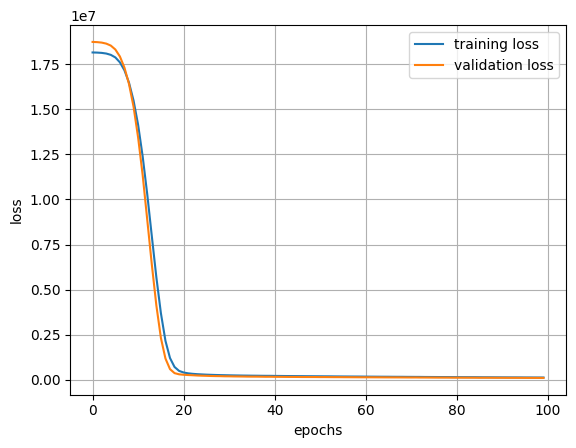

In [ ]:
plt.plot(learned.history['loss'],label='training loss')
plt.plot(learned.history['val_loss'],label='validation loss')
plt.legend()
plt.grid(True)
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()

In [ ]:
new_data=np.array([[5.1,3.5,1.4,0.2],[6.0,2.7,4.2,1.3]])
new_data=scaler.transform(new_data)
predictions=model.predict(new_data)
predicted_class=np.argmax(predictions,axis=1)
predicted_class

In [ ]:
#diamonds
dd=sns.load_dataset('diamonds')
dd.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [ ]:
dd.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [ ]:
dd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [ ]:
dd.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


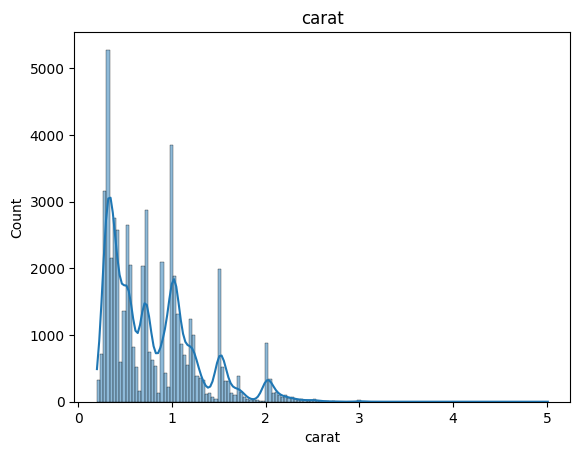

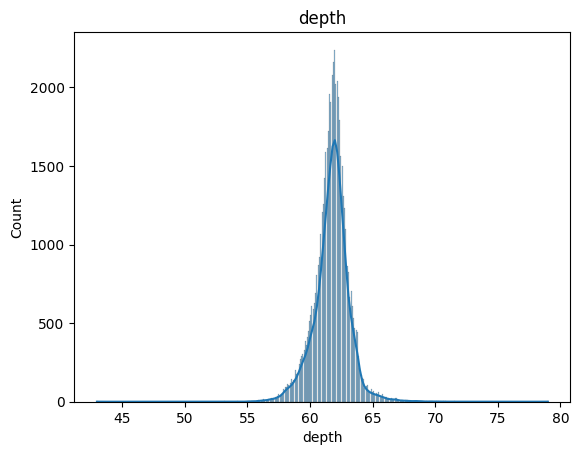

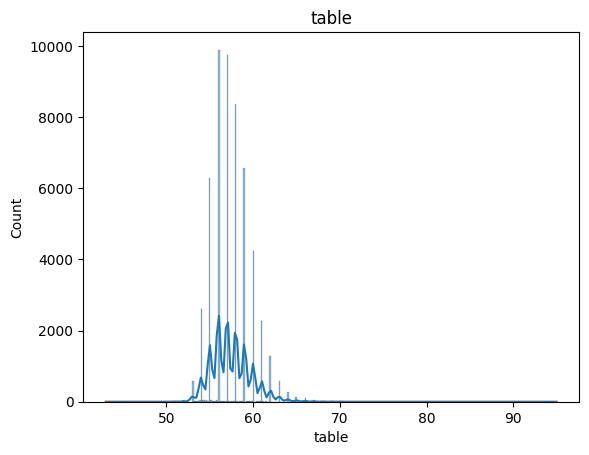

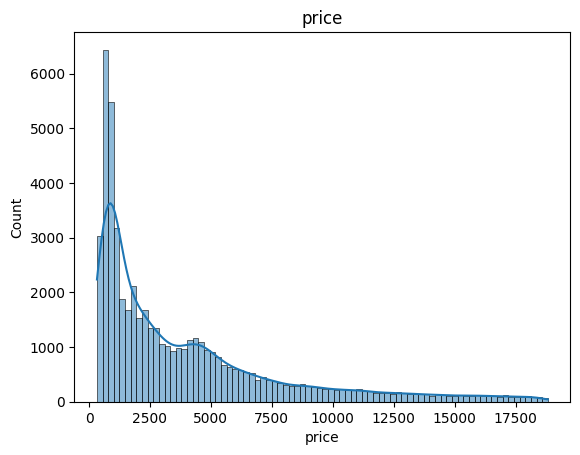

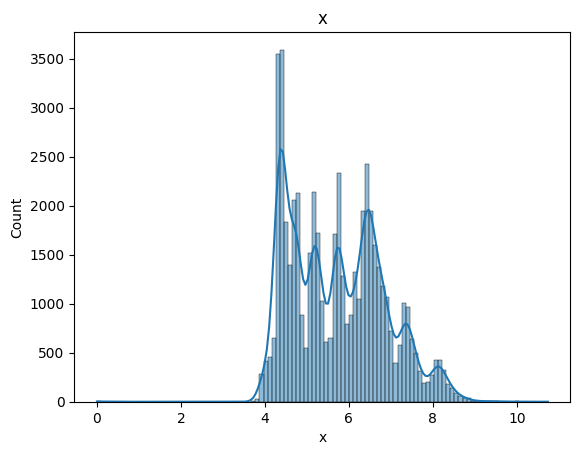

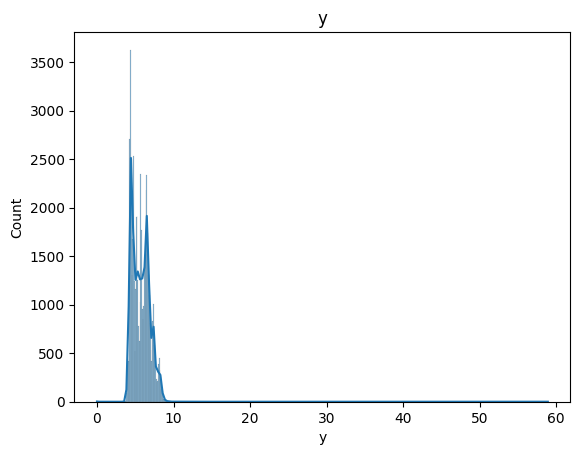

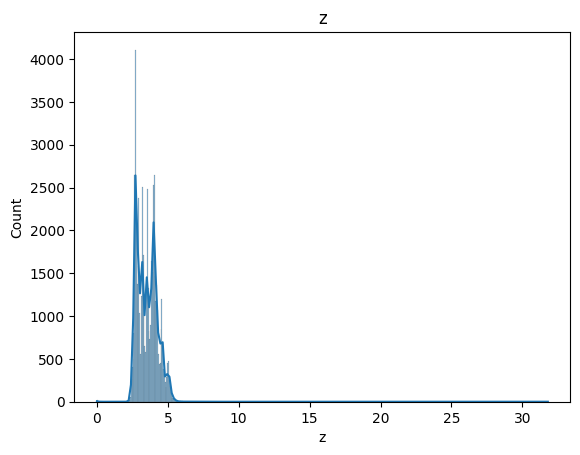

In [ ]:
numerical_cols=dd.select_dtypes(include=np.number).columns
numerical_cols
for col in numerical_cols:
  sns.histplot(dd[col],kde=True)
  plt.title(col)
  plt.show()

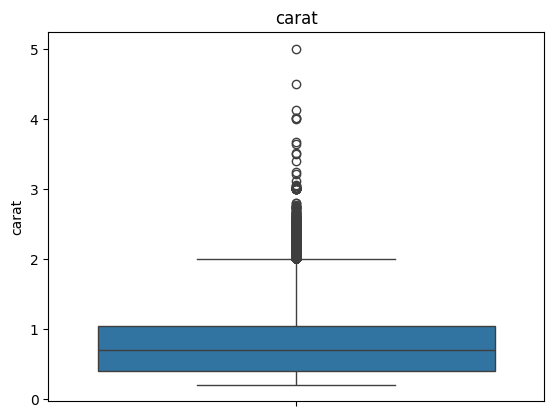

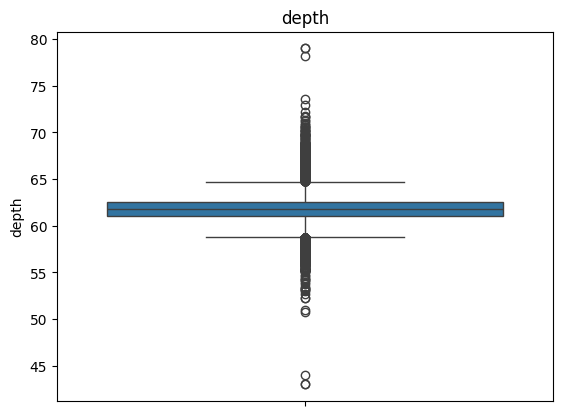

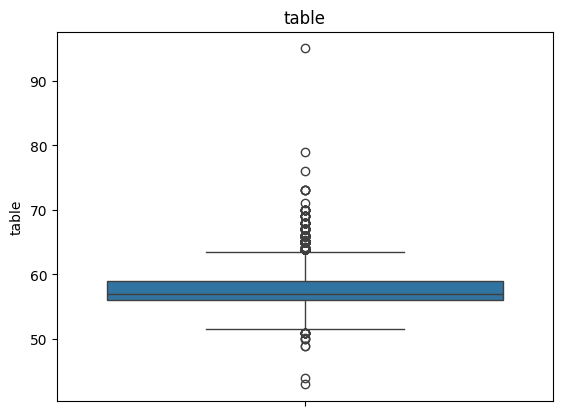

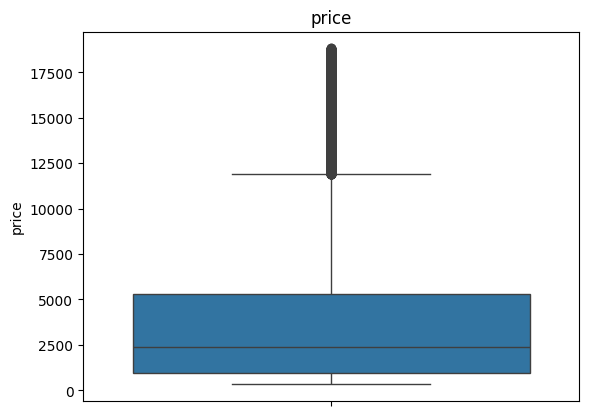

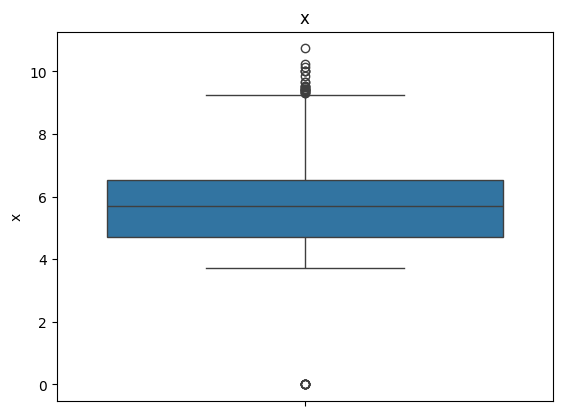

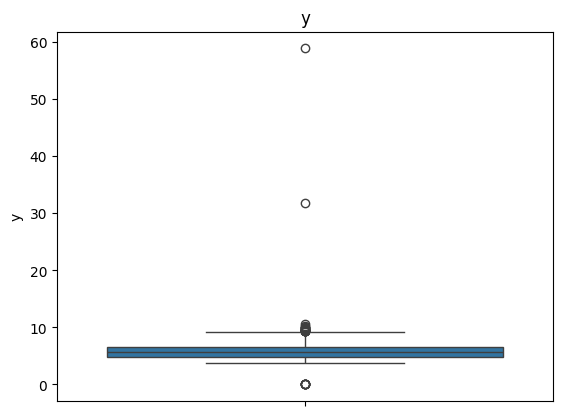

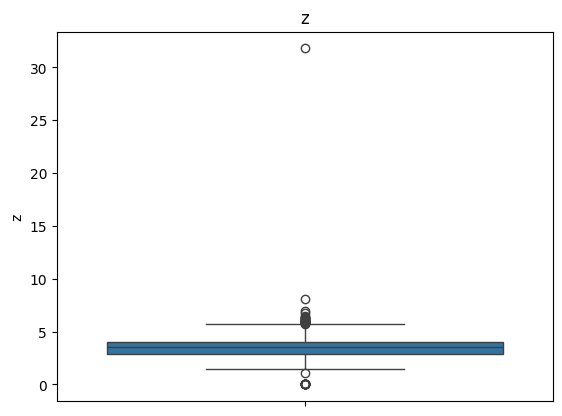

In [ ]:
numerical_cols=dd.select_dtypes(include=np.number).columns
numerical_cols
for col in numerical_cols:
  sns.boxplot(dd[col])
  plt.title(col)
  plt.show()

In [ ]:
dd['x'].min()

0.0

In [ ]:
dd['x'].value_counts()

,count
x,
4.37,448
4.34,437
4.33,429
4.38,428
4.32,425
...,...
8.89,1
9.36,1
10.74,1


In [ ]:
dd[['x','y','z']]=dd[['x','y','z']].replace(0,np.nan)
dd.dropna(subset=['x','y','z'],inplace=True)
dd.shape

(53920, 10)

In [ ]:
dd['cut'].value_counts()


,count
cut,
Ideal,21548
Premium,13780
Very Good,12081
Good,4902
Fair,1609


In [ ]:
cut=['Fair','Good','Very Good','Premium','Ideal']
color=['J','I','H','G','F','E','D']
clarity=['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF']

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
oe=OrdinalEncoder(categories=[cut,color,clarity])
dd[['cut','color','clarity']]=oe.fit_transform(dd[['cut','color','clarity']])
dd.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,4.0,5.0,1.0,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3.0,5.0,2.0,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1.0,5.0,4.0,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3.0,1.0,3.0,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1.0,0.0,1.0,63.3,58.0,335,4.34,4.35,2.75


In [ ]:
columns=['carat','depth','table','x','y','z','price']
for col in columns:
  dd[col]=np.log1p(dd[col])
dd.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.207014,4.0,5.0,1.0,4.135167,4.025352,5.789960,1.599388,1.605430,1.232560
1,0.190620,3.0,5.0,2.0,4.107590,4.127134,5.789960,1.587192,1.576915,1.196948
2,0.207014,1.0,5.0,4.0,4.058717,4.189655,5.793014,1.619388,1.623341,1.196948
3,0.254642,3.0,1.0,3.0,4.149464,4.077537,5.814131,1.648659,1.654411,1.289233
4,0.270027,1.0,0.0,1.0,4.163560,4.077537,5.817111,1.675226,1.677097,1.321756


In [ ]:
X=dd.drop(columns=['price'],axis=1)
y=dd['price']

In [ ]:
X

,carat,cut,color,clarity,depth,table,x,y,z
0,0.207014,4.0,5.0,1.0,4.135167,4.025352,1.599388,1.605430,1.232560
1,0.190620,3.0,5.0,2.0,4.107590,4.127134,1.587192,1.576915,1.196948
2,0.207014,1.0,5.0,4.0,4.058717,4.189655,1.619388,1.623341,1.196948
3,0.254642,3.0,1.0,3.0,4.149464,4.077537,1.648659,1.654411,1.289233
4,0.270027,1.0,0.0,1.0,4.163560,4.077537,1.675226,1.677097,1.321756
...,...,...,...,...,...,...,...,...,...
53935,0.542324,4.0,6.0,2.0,4.123903,4.060443,1.909543,1.911023,1.504077
53936,0.542324,1.0,6.0,2.0,4.160444,4.025352,1.900614,1.909543,1.528228
53937,0.530628,2.0,6.0,2.0,4.155753,4.110874,1.896119,1.899118,1.517323
53938,0.620576,3.0,2.0,1.0,4.127134,4.077537,1.967112,1.962908,1.556037


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input

In [ ]:
model=Sequential()
model.add(Input(shape=(9,)))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(1,activation='linear'))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

model.compile(optimizer='adam',loss='mse',metrics=['mae','mse','r2_score'])

In [ ]:
learned=model.fit(X_train,y_train,epochs=100,batch_size=32,verbose=1,validation_data=(X_test,y_test))


Epoch 1/100
1348/1348 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 9.1402 - mae: 1.8263 - mse: 9.1402 - r2_score: -7.7862 - val_loss: 0.0687 - val_mae: 0.1471 - val_mse: 0.0687 - val_r2_score: 0.9332
Epoch 2/100
1348/1348 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0367 - mae: 0.1411 - mse: 0.0367 - r2_score: 0.9642 - val_loss: 0.0378 - val_mae: 0.1220 - val_mse: 0.0378 - val_r2_score: 0.9632
Epoch 3/100
1348/1348 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.0239 - mae: 0.1174 - mse: 0.0239 - r2_score: 0.9765 - val_loss: 0.0267 - val_mae: 0.1064 - val_mse: 0.0267 - val_r2_score: 0.9740
Epoch 4/100
1348/1348 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0206 - mae: 0.1101 - mse: 0.0206 - r2_score: 0.9800 - val_loss: 0.0222 - val_mae: 0.0984 - val_mse: 0.0222 - val_r2_score: 0.9784
Epoch 5/100
1348/1348 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0189 - mae: 0.1061 - mse: 0.0189 - r2_score: 0.9818 - val_loss: 0.0212 - val_mae: 0.1005 - val_mse: 0.0212 - val_r2_score: 0.9793
Epoch 6/100
1348/1348 ━━

In [ ]:
loss,mae,mse,r2=model.evaluate(X_test,y_test,verbose=0)
print(loss)
print(mae)
print(mse)
print(r2)

0.012062549591064453
0.08204872161149979
0.012062549591064453
0.988262414932251


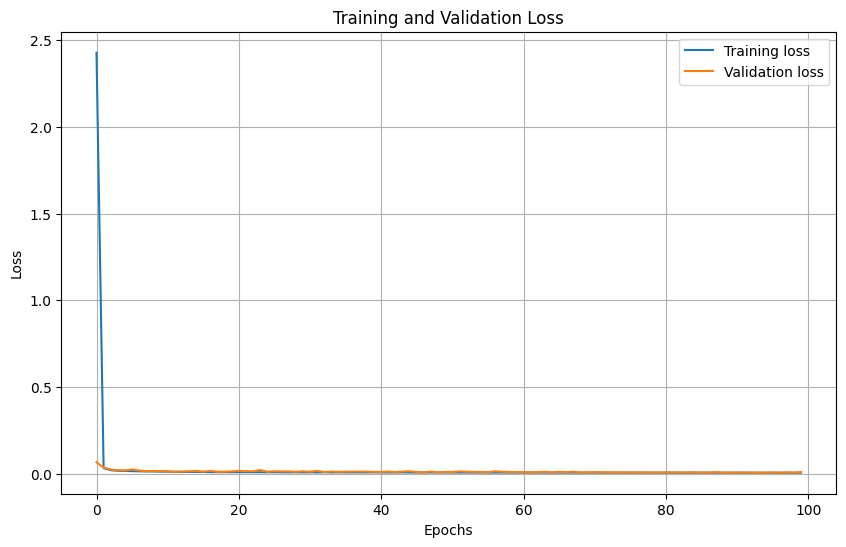

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(learned.history['loss'],label='Training loss')
plt.plot(learned.history['val_loss'],label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()